In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
from matplotlib import ticker, cm
import mpl_toolkits.axes_grid1 as ag
import pandas as pd
from sklearn.metrics import r2_score
import sys
%matplotlib inline

### Lectura de la DB

Text(0, 0.5, 'Life expectancy')

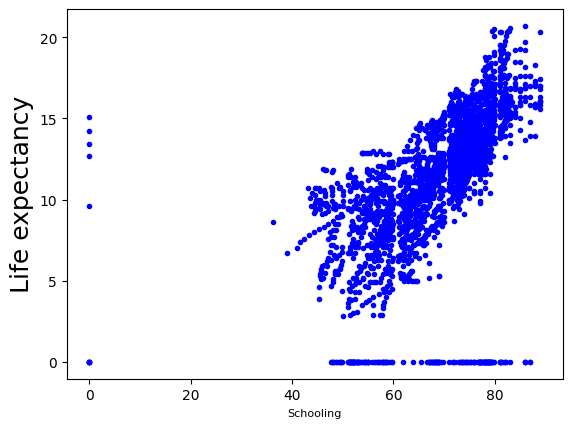

In [2]:
df = pd.read_csv('Life_Expectancy_Data.csv')
df= df.fillna(0)
# print(df.columns)
x = df[['Life expectancy ']]
x = x.to_numpy()
y = df['Schooling']
y = y.to_numpy()
plt.plot(x,y,'b.')
plt.xlabel("Schooling", fontsize=8)
plt.ylabel("Life expectancy", rotation=90, fontsize=18)

### z-score y acomodo de dimensiones

In [3]:
y=y.reshape((len(y), 1)) # dimension (m,1)
x_b = np.c_[np.ones((len(x),1)),x] # adding x0, dimension (m,n) 
x_bs=x_b.copy() #initializing standardized vector

#z-scores standarization 
for it in range(1,x_bs.shape[1]):
    m=np.mean(x_b[:,it])
    std=np.std(x_b[:,it])
    x_bs[:,it]=(x_b[:,it]-m)/std
      

### Gradiente de descendente 

[[11.32743363]
 [ 2.39512701]]
10599


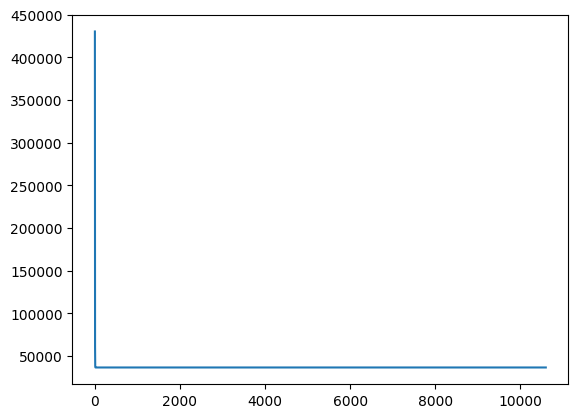

In [4]:
theta = np.array([[0],[0]]) #initializing parameters dimension (n,1)
ep=1e-15 #stopping criterion
lr =1e-4 # learning rate
itera = 10600 #stopping criterion
J=[] #initializing history of cost function 
Theta_DG=[]
#iterations 
for it in range(itera):
    #Gradient
    Theta_DG.append(theta)
    pred = x_bs@theta #prediction 
    r=(pred - y) #residual 
    si=x_bs.T@r#search direction 
    theta = theta -lr*si # parameter minimum estimation
    J.append(np.sum(r**2)) #cost
    if np.sqrt(si[0]**2+si[1]**2)<ep: #stopping criterion 
        break
Theta_DG=np.array(Theta_DG)
print(theta)
print(it)
plt.plot(J)
plt.show()

[[11.322533  ]
 [ 2.32427539]]
10599


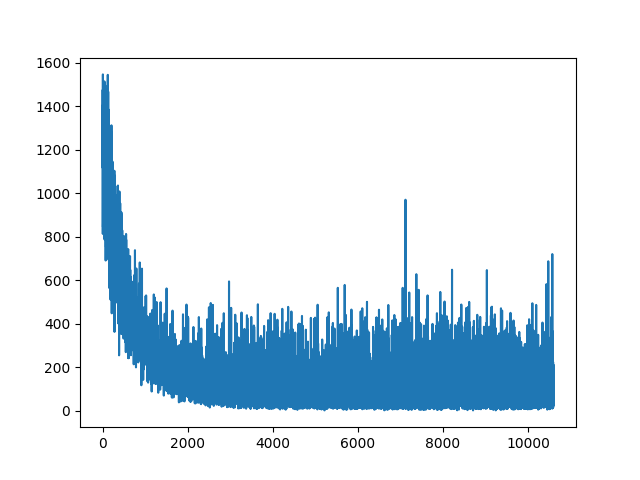

In [ ]:
MB = 8
N=len(y)
theta = np.array([[0],[0]])
ep=1e-10
lr =1e-3
β = 0.9
n_iter =10600
J=[] #initializing history of cost function 
Theta_SDG=[]
v = theta*0 
for it in range(n_iter):
    rand_ind = np.random.randint(0,N,MB)
    x_i = x_bs[rand_ind,:].reshape(MB,x_bs.shape[1])
    y_i = y[rand_ind].reshape(MB,1)
    pred = np.dot(x_i,theta)
    h = pred - y_i
    si = x_i.T.dot((h))
    si = β*v+ (1-β)*si
    theta = theta -lr*si
    if np.sqrt(si[0]**2+si[1]**2)<ep: #stopping criterion 
        break
    J.append(np.sum(h**2)) #cost
    Theta_SDG.append(theta)
Theta_SDG=np.array(Theta_SDG)
print(theta)
print(it)
fig = plt.figure()
plt.plot(J)
plt.show()

# theta_0=12.894598 theta_1= 3.023298
# theta_0=13.098372 theta_1= 3.095889

Text(0.5, 0, 'Iteración')

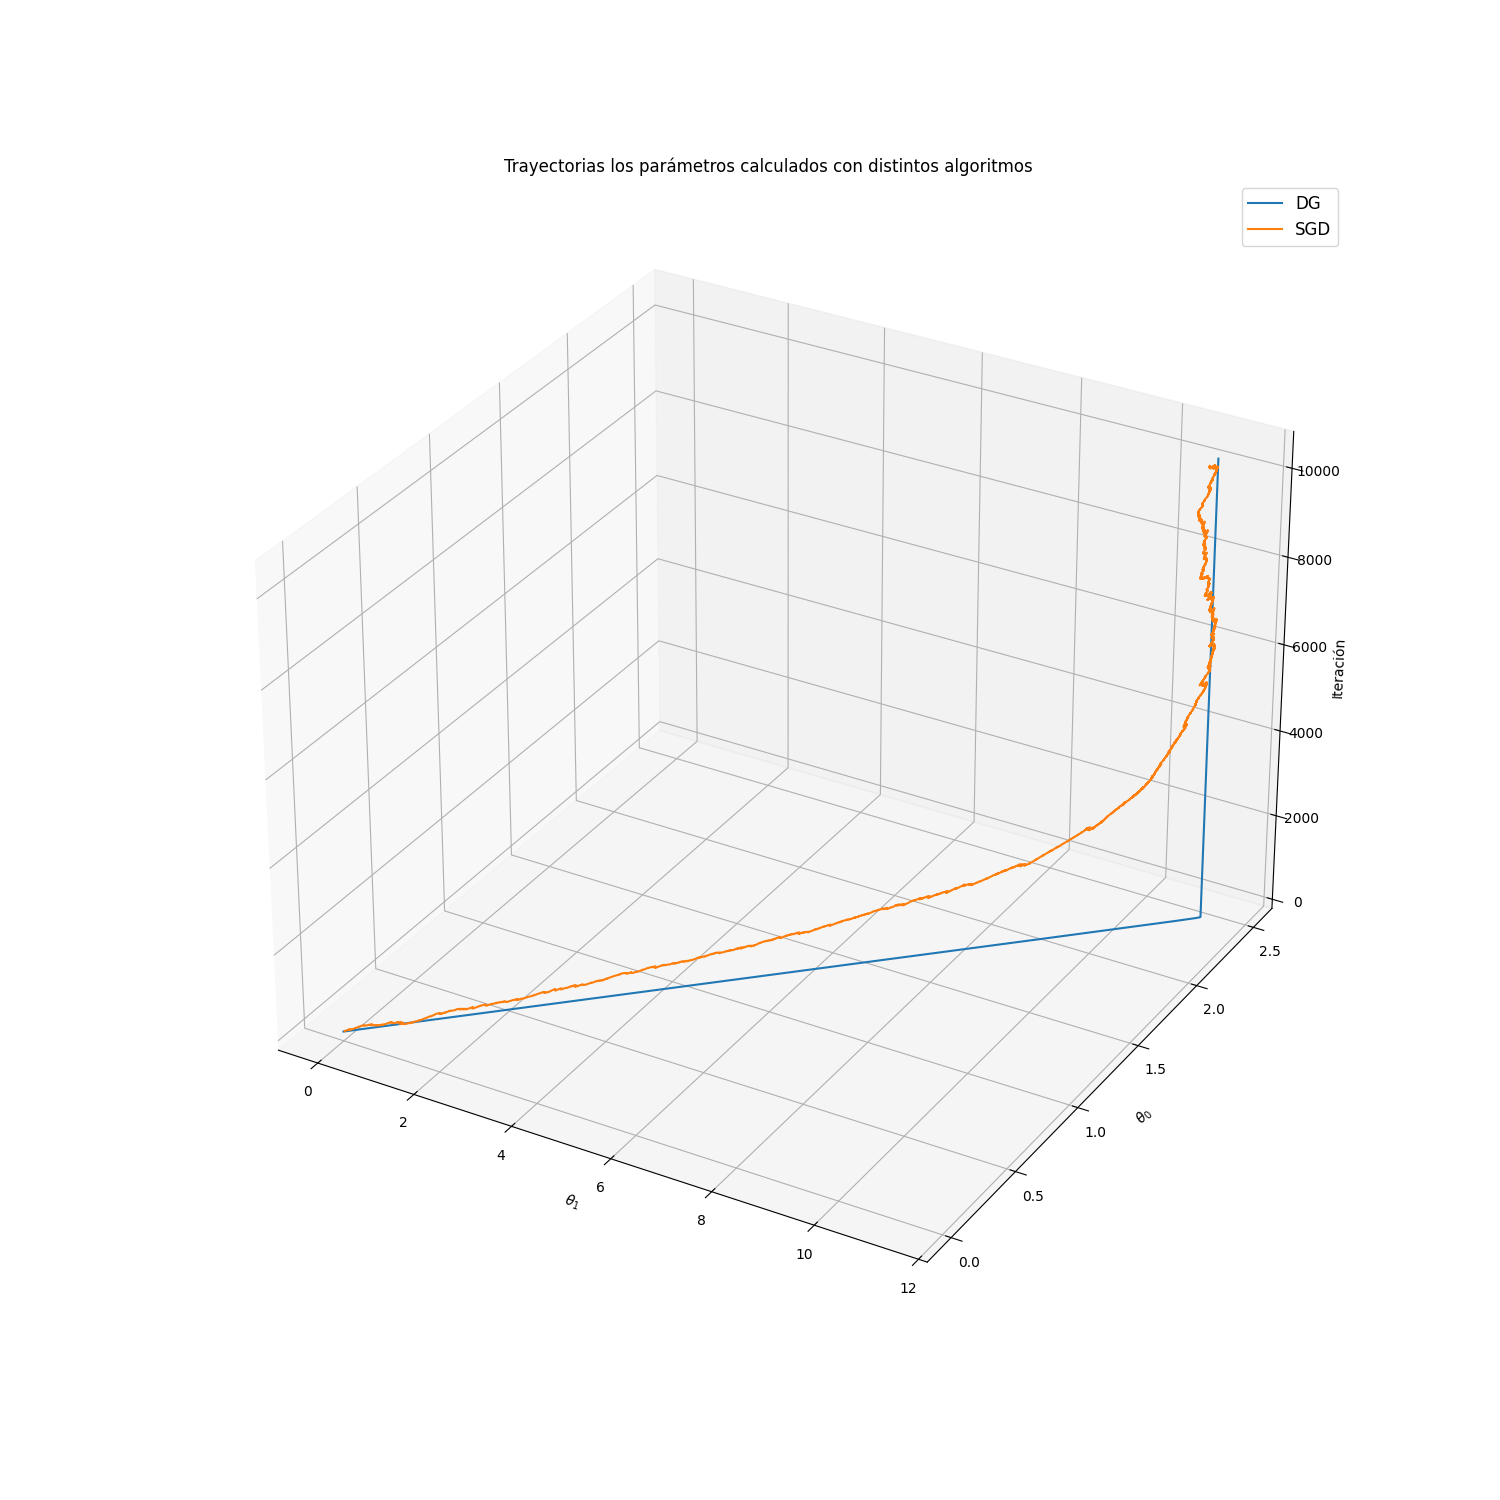

In [16]:
%matplotlib widget
mpl.rcParams['legend.fontsize'] = 12
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111, projection='3d')
nIter=np.expand_dims(np.arange(Theta_DG.shape[0]),1) 
ax.plot(Theta_DG[:,0],  Theta_DG[:,1], nIter[:], label='DG')
ax.plot(Theta_SDG[:,0], Theta_SDG[:,1], nIter[:], label='SGD')
ax.legend()
ax.set_title(r'Trayectorias los parámetros calculados con distintos algoritmos')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_0$')
ax.set_zlabel('Iteración')